In [1]:
# Imports
from config import *

import os
os.environ["COBAYA_NOMPI"] = "true"  # this notebook doesn't run under MPI; skip mpi4py import so it works without an openmpi module loaded

import cobaya
import cobaya.samplers.mcmc
import getdist.plots as gdplt
import yaml, re
from Models.Papers import Amodeo2021
%matplotlib inline

# import cobaya, yaml, getdist

# Before submission

### Run Model with Cobaya

In [27]:
# Reload every modules to updates
import ForwardModel as SZobs
importlib.reload(SZobs)
import SOLikelihoods
importlib.reload(SOLikelihoods)

# Define YAML file and print steps
yaml_name = "L25"

yaml_file = f"{CAPPIBARAS_PATH}/yamls/{yaml_name}.yaml"
yamlinfo = cobaya.yaml.yaml_load_file(yaml_file).copy()
for key in yamlinfo['likelihood']:
    yamlinfo['likelihood'][key]['YAML_FILE'] = yaml_file
    yamlinfo['likelihood'][key]['VERBOSE'] = True
    yamlinfo['likelihood'][key]['PAPERCHECK'] = True

likelis = cobaya.get_model(yamlinfo).likelihood

[model] *WARNING* Ignored blocks/options: ['shared']


Loading in Fixed Parameters and Data/Model Dictionaries from yaml file

Importing pyccl Cosmology from Models.Codes
Initializing with {'h': 0.6736, 'Omega_m': 0.3137, 'Omega_b': 0.0493, 'sigma8': 0.811355, 'n_s': 0.9649, 'T_CMB': 2.725, 'XH': 0.76}

Importing pyccl HaloModel from Models.Codes
Initializing with {'MassDef': '200c', 'MassFunc': 'Tinker08', 'HaloBias': 'Tinker10', 'Concentration': 'Diemer15'}

Importing Liu2025 Measurement from Models.Papers
Initializing with {'zbin': 'z1', 'ACTDR': 'DR6', 'Beta': 'fiducial', 'dp': 'dBeta', 'TCIB': '10.7'}

Importing Liu2025 TargetData from Models.Papers
Initializing with {'zbin': 'z1', 'zNum': 10, 'zMin': 0.3, 'zMax': 0.7, 'logMhNum': 20, 'logMhMin': 10, 'logMhMax': 15}
Paper: nan < z < nan, zMean = 0.47
Model: 0.32 < z < 0.68, zMean = 0.47, dz = 0.04
Paper: nan < logMh < nan, logMhMean = 13.40
Model: 10.00 < logMh < 15.00, logMhMean = 13.40, dlogMh = 0.26

Importing Coulton2024 MapData from Models.Papers
Initializing with {}

Importing P

In [28]:
def get_param_results(params, likelis_in):
    results = {}
    for likeli in likelis_in.values():
        theory = np.asarray(likeli.model(params))
        delta = likeli.data.y - theory
        chi2_real = delta @ likeli.data.inv_cov @ delta  # true chi^2, no norm_const/logdet offset

        results[likeli.get_name()] = {
            'chi2overN': chi2_real/len(likeli.data.x),
            'tot': likeli.model(params),
            '1h': likeli.prof_to_obs(likeli.average_prof(likeli.prof1h(params))),
            '2h': likeli.prof_to_obs(likeli.average_prof(likeli.prof2h(params))),
            'proftot': likeli.average_prof(likeli.prof(params)),
            'prof1h': likeli.average_prof(likeli.prof1h(params)),
            'prof2h': likeli.average_prof(likeli.prof2h(params))
        }

    return results

In [29]:
from Models.Papers import Amodeo2021
importlib.reload(Amodeo2021)
    
def plot_results(results_list, likelis_in):
    nrows = len(likelis_in)
    fig, axs = plt.subplots(nrows, 2, figsize=(10, 4*nrows), layout='constrained')
    if nrows == 1:
        axs = axs[None, :]

    fig6 = Amodeo2021.Fig6()

    for (axprof, axdata), likeli in zip(axs, likelis_in.values()):
        name = likeli.get_name()

        # Overlay the published Fig6 density/pressure panel behind the profile
        # plot (axprof only); axdata is left completely untouched.
        overlay = "kSZ" in name or "tSZ" in name or "y" in name
        if "kSZ" in name:
            fig6.panel_on(axprof, row=0, col=0)
        elif "tSZ" in name or "y" in name:
            fig6.panel_on(axprof, row=0, col=1)

        # Left: 1h/2h/total profile (pre-projection) vs r
        for results in results_list:
            vers = results['results'][name]
            label = results['label']
            color = results['color']

            axprof.scatter(likeli.r, vers['prof1h'].cgs, marker='.', c=color, alpha=0.8)
            axprof.scatter(likeli.r, vers['prof2h'].cgs, marker='.', c=color, alpha=0.8)
            axprof.scatter(likeli.r, vers['proftot'].cgs, marker='o', label=label, c=color, alpha=0.8)
            
            axdata.plot(likeli.data.x, vers['1h'], ls='--', lw=1, c=color, alpha=0.5)
            axdata.plot(likeli.data.x, vers['2h'], ls=':', lw=1, c=color, alpha=0.5)
            axdata.plot(likeli.data.x, vers['tot'], lw=3, label=rf"{label}: $\chi^2/N=${vers['chi2overN']:.2f}", c=color, alpha=0.5)
            
        # Right: data and projected SZ signal
        axdata.errorbar(likeli.data.x, likeli.data.y, np.diag(likeli.data.cov)**0.5, label='data', c='white', marker='o', capsize=10, ls='None', alpha=0.9)

        if overlay:
            # Fig6's own xscale/yscale/xlim/ylim/labels already match the
            # background image (set by panel_on above) -- don't clobber them.
            axprof.set(title=name)
        else:
            axprof.set(xscale='log', yscale='log', ylim=(None, None), xlabel=r'$r$', title=name)
        axprof.legend()
        axdata.legend(title=name)
        if "kSZ" in name:
            axdata.set(yscale='log', ylim=(5e-2, 5e1), ylabel=r'$T_{kSZ} \ [\mu \text{K} \ \text{arcmin}^2]$', xlabel=r'$\theta$ [arcmin]')
        elif "tSZ" in name:
            axdata.set(ylim=(-0.5e-6, 6e-6), ylabel=r'$y$', xlabel=r'$\theta$ [arcmin]')

    plt.show()

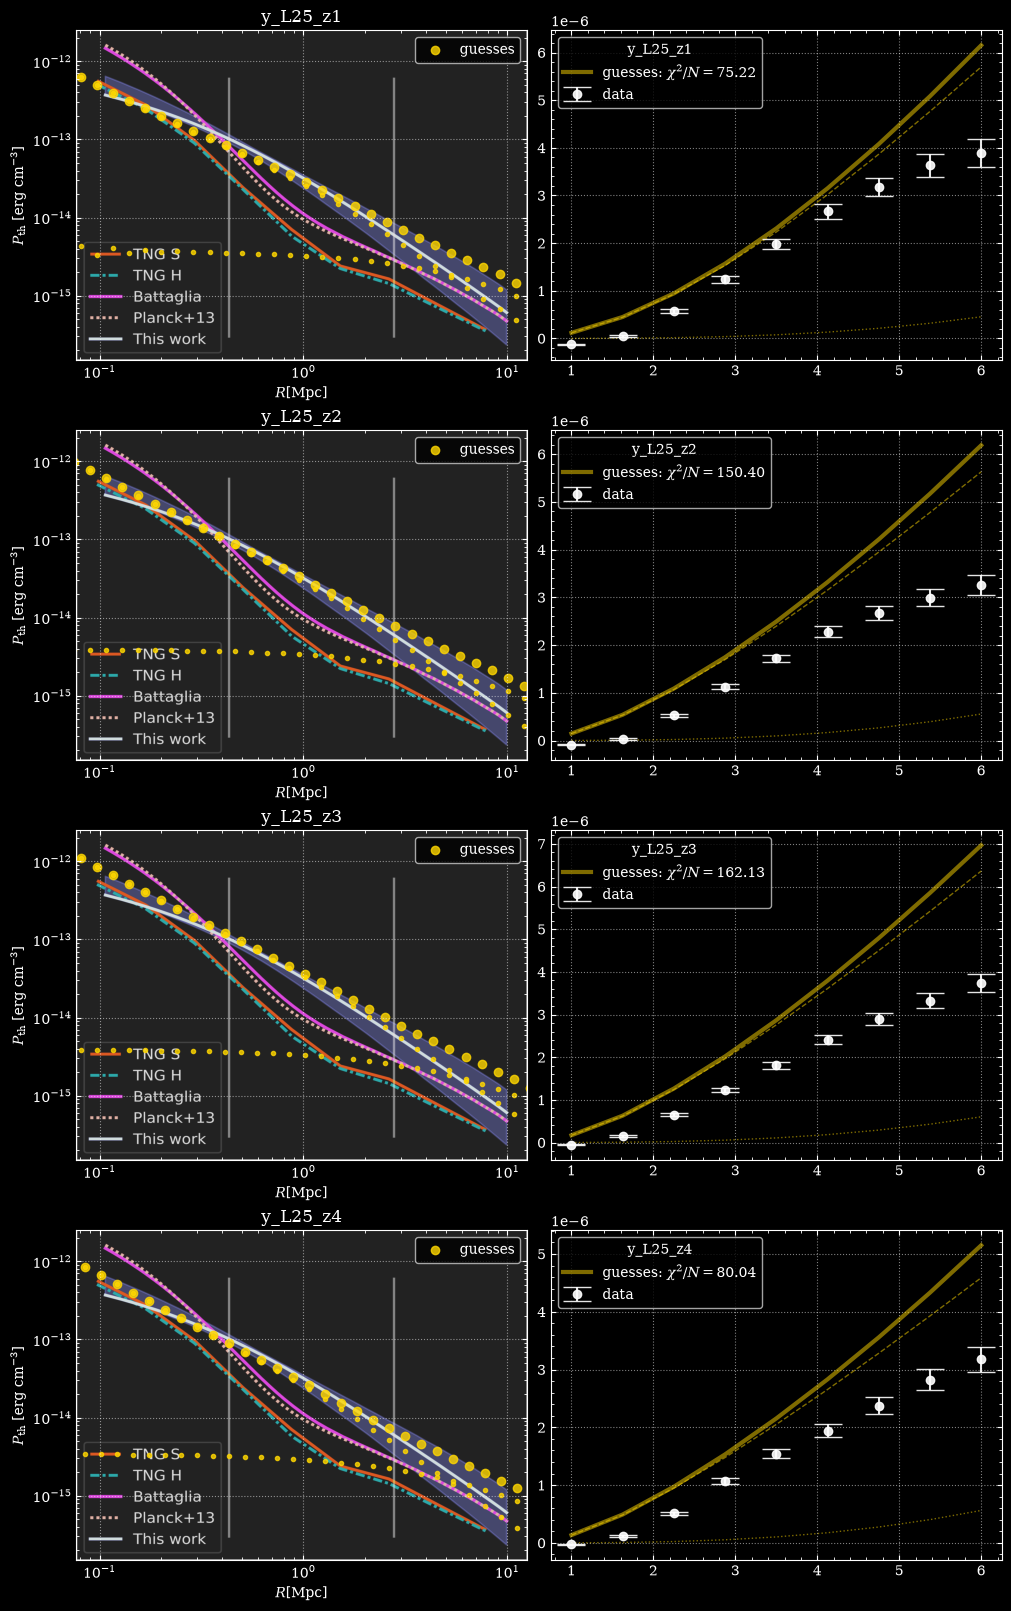

In [32]:
# guessparams = {'rho0': 2,
#  'xc_rho': 0.5,
#  'gamma_rho': -0.2,
#  'alpha_rho': 0.8,
#  'beta_rho': 3,
#  'A_2h_rho': 1}

guessparams = {'P0': 10,
 'xc_P': 0.5,
 'gamma_P': -1,
 'alpha_P': 0.3,
 'beta_P': 3.6,
 'A_2h_P': 1}

guesses = get_param_results(guessparams, likelis)

plot_results([
    {'label': 'guesses', 'results': guesses, 'color': 'gold'},
    ], likelis)

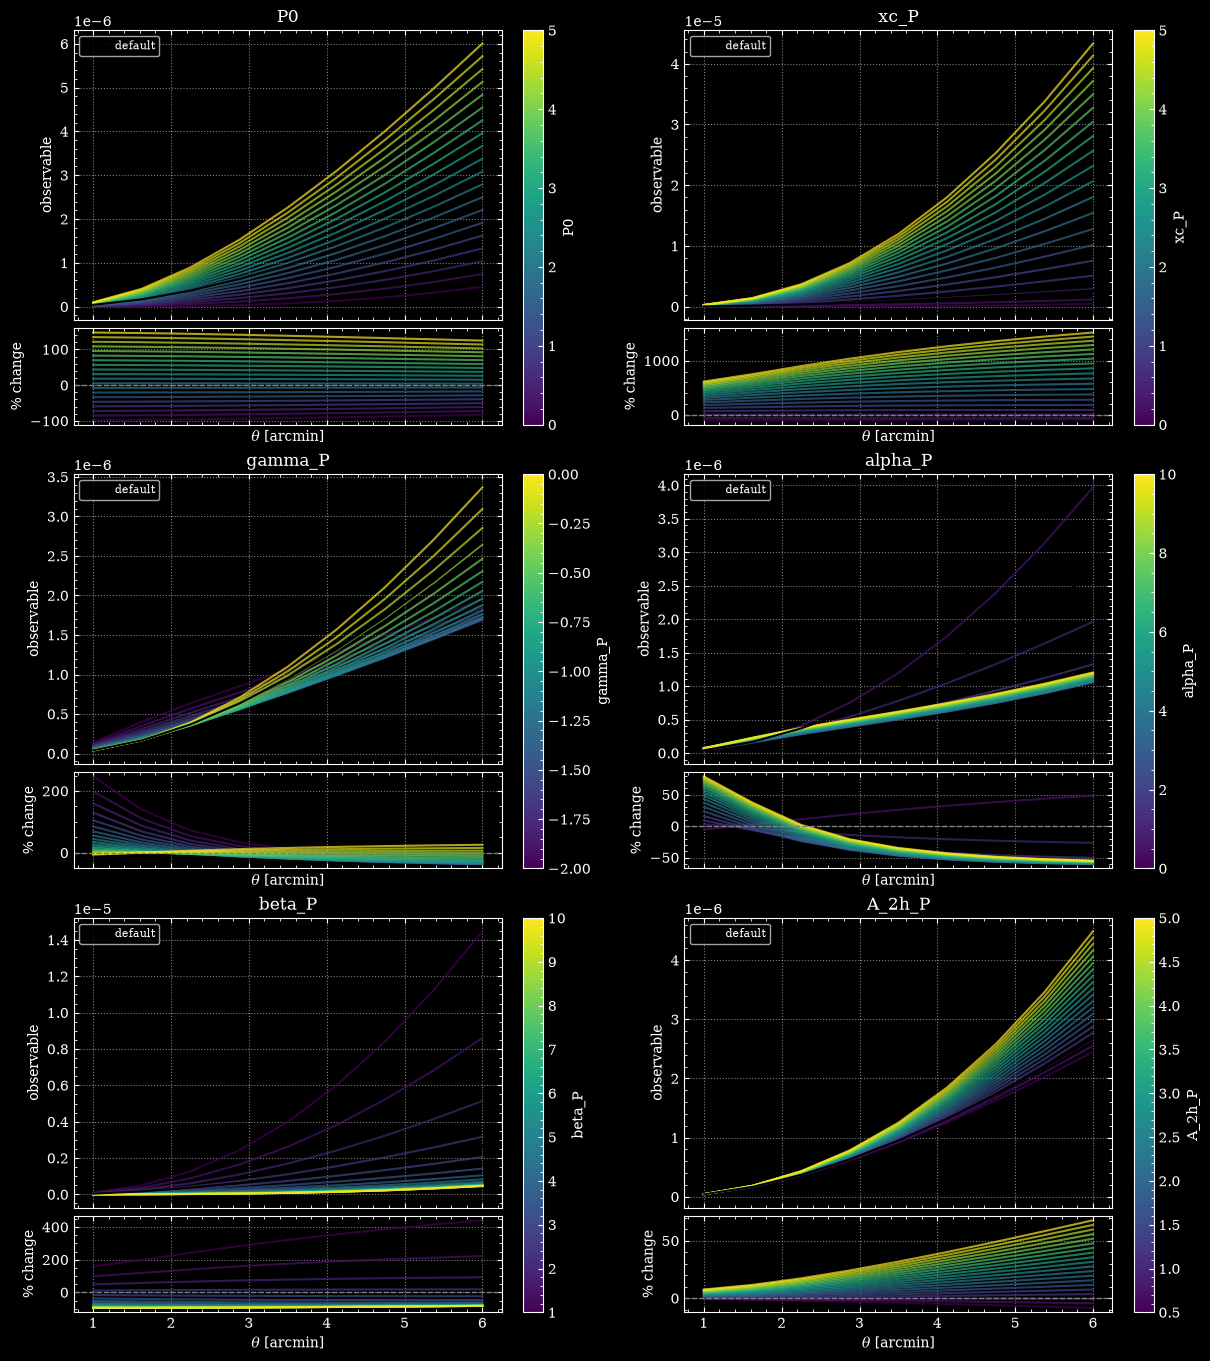

In [34]:
# Prior ranges from runchainsRiedGuachalla_2.yaml (including commented-out priors for xc_rho, gamma_rho)
# param_ranges = {
#     'rho0':     (0, 5),
#     'xc_rho':   (0, 5),
#     'gamma_rho': (-2, 0),
#     'alpha_rho': (0, 10),
#     'beta_rho': (1, 10),
#     'A_2h_rho': (0.5, 5),
# }
param_ranges = {
    'P0':     (0, 5),
    'xc_P':   (0, 5),
    'gamma_P': (-2, 0),
    'alpha_P': (0, 10),
    'beta_P': (1, 10),
    'A_2h_P': (0.5, 5),
}

likeli = list(likelis.values())[0]  # use the first likelihood for plotting
default = likeli.model({})  # default model to compare against

ncols = 2  # parameters per row
nblocks = int(np.ceil(len(param_ranges) / ncols))  # rows of parameters

cmap = plt.cm.viridis
# Each parameter gets a tall observable panel with a short percent-diff panel
# stacked below it. 2*nblocks rows x ncols cols, sharing x per column.
fig, axs = plt.subplots(2*nblocks, ncols, figsize=(6*ncols, 4.5*nblocks),
                        layout='constrained', sharex='col', squeeze=False,
                        gridspec_kw={'height_ratios': [3, 1] * nblocks})

for i, (param, (pmin, pmax)) in enumerate(param_ranges.items()):
    block, col = divmod(i, ncols)
    ax_obs = axs[block*2, col]      # main: actual observable
    ax_pct = axs[block*2 + 1, col]  # subplot below: percent diff

    vals = np.linspace(pmin, pmax, 20)
    norm = plt.Normalize(pmin, pmax)
    for v in vals:
        model = likeli.model({param: v})
        ax_obs.plot(likeli.data.x, model, color=cmap(norm(v)), alpha=0.7)
        pct = 100 * (model - default) / default
        ax_pct.plot(likeli.data.x, pct, color=cmap(norm(v)), alpha=0.7)

    sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
    fig.colorbar(sm, ax=[ax_obs, ax_pct], label=param)

    ax_obs.plot(likeli.data.x, default, color='k', lw=1.5, label='default')
    ax_pct.axhline(0, color='gray', ls='--', lw=1)

    ax_obs.set(title=param, ylabel='observable', yscale='linear')
    ax_obs.legend(fontsize=8)
    ax_pct.set(xlabel=r'$\theta$ [arcmin]', ylabel='% change')

plt.show()

### Run a quick minimizer

In [35]:
yamlinfo['output'] = f"{OUTPUT_PATH}/minimizer_runs/{yaml_name}"
yamlinfo['sampler'] = {"minimize": {'ignore_prior': True, 'best_of': 100}}
for key in yamlinfo['likelihood']:
    yamlinfo['likelihood'][key]['VERBOSE'] = True

mini_info, mini_out = cobaya.run(yamlinfo, force=True)

likelis = mini_out.model.likelihood

INFO:output:Output to be read-from/written-into folder '/mnt/ceph/users/cpopik/CAPPIBARAS_runs/minimizer_runs', with prefix 'L25'


[output] Output to be read-from/written-into folder '/mnt/ceph/users/cpopik/CAPPIBARAS_runs/minimizer_runs', with prefix 'L25'


INFO:output:Found existing info files with the requested output prefix: '/mnt/ceph/users/cpopik/CAPPIBARAS_runs/minimizer_runs/L25'


[output] Found existing info files with the requested output prefix: '/mnt/ceph/users/cpopik/CAPPIBARAS_runs/minimizer_runs/L25'


INFO:output:Will delete previous products ('force' was requested).


...

[minimize] -log(likelihood) minimized to -5.5428


INFO:minimize:Parameter values at minimum:
   weight  minuslogpost        P0      xc_P    gamma   alpha      beta  A_2h_P  minuslogprior  minuslogprior__0       chi2  chi2__y_L25_z1  chi2__y_L25_z2  chi2__y_L25_z3  chi2__y_L25_z4
0     1.0      6.482161  0.454219  1.512473 -0.20865  2.3287  6.214911     0.5      12.024964         12.024964 -11.085605       52.287902       92.554928       -21.39186     -134.536575


[minimize] Parameter values at minimum:
   weight  minuslogpost        P0      xc_P    gamma   alpha      beta  A_2h_P  minuslogprior  minuslogprior__0       chi2  chi2__y_L25_z1  chi2__y_L25_z2  chi2__y_L25_z3  chi2__y_L25_z4
0     1.0      6.482161  0.454219  1.512473 -0.20865  2.3287  6.214911     0.5      12.024964         12.024964 -11.085605       52.287902       92.554928       -21.39186     -134.536575


INFO:minimize:Full set of minima:
{'0': (17.182446017738556, True), '1': (42.59811708455142, True), '2': (70.2797145388514, True), '3': (40.74333043202478, True), '4': (15.433656792269204, True), '5': (60.906793696385776, True), '6': (36.52028746577933, True), '7': (0.5258143053155635, True), '8': (39.35509033621308, True), '9': (42.990336703795535, True), '10': (46.96705369400544, True), '11': (-5.542802451421991, True), '12': (16.997184552479283, True), '13': (39.345740235984124, True), '14': (20.754525926535464, True), '15': (61.89248243618452, True), '16': (68.41645765961573, True), '17': (5.146294845994888, True), '18': (23.247400063777548, True), '19': (19.464665562020826, True), '20': (17.236682404369006, True), '21': (106.43250191865127, True), '22': (23.11542320625729, True), '23': (49.93218282509618, True), '24': (127.51269597805016, True), '25': (54.85297596212145, True), '26': (37.537069265878145, True), '27': (45.169442149514964, True), '28': (150.72940319490436, True), '2

[minimize] Full set of minima:
{'0': (17.182446017738556, True), '1': (42.59811708455142, True), '2': (70.2797145388514, True), '3': (40.74333043202478, True), '4': (15.433656792269204, True), '5': (60.906793696385776, True), '6': (36.52028746577933, True), '7': (0.5258143053155635, True), '8': (39.35509033621308, True), '9': (42.990336703795535, True), '10': (46.96705369400544, True), '11': (-5.542802451421991, True), '12': (16.997184552479283, True), '13': (39.345740235984124, True), '14': (20.754525926535464, True), '15': (61.89248243618452, True), '16': (68.41645765961573, True), '17': (5.146294845994888, True), '18': (23.247400063777548, True), '19': (19.464665562020826, True), '20': (17.236682404369006, True), '21': (106.43250191865127, True), '22': (23.11542320625729, True), '23': (49.93218282509618, True), '24': (127.51269597805016, True), '25': (54.85297596212145, True), '26': (37.537069265878145, True), '27': (45.169442149514964, True), '28': (150.72940319490436, True), '29':

### Plot results

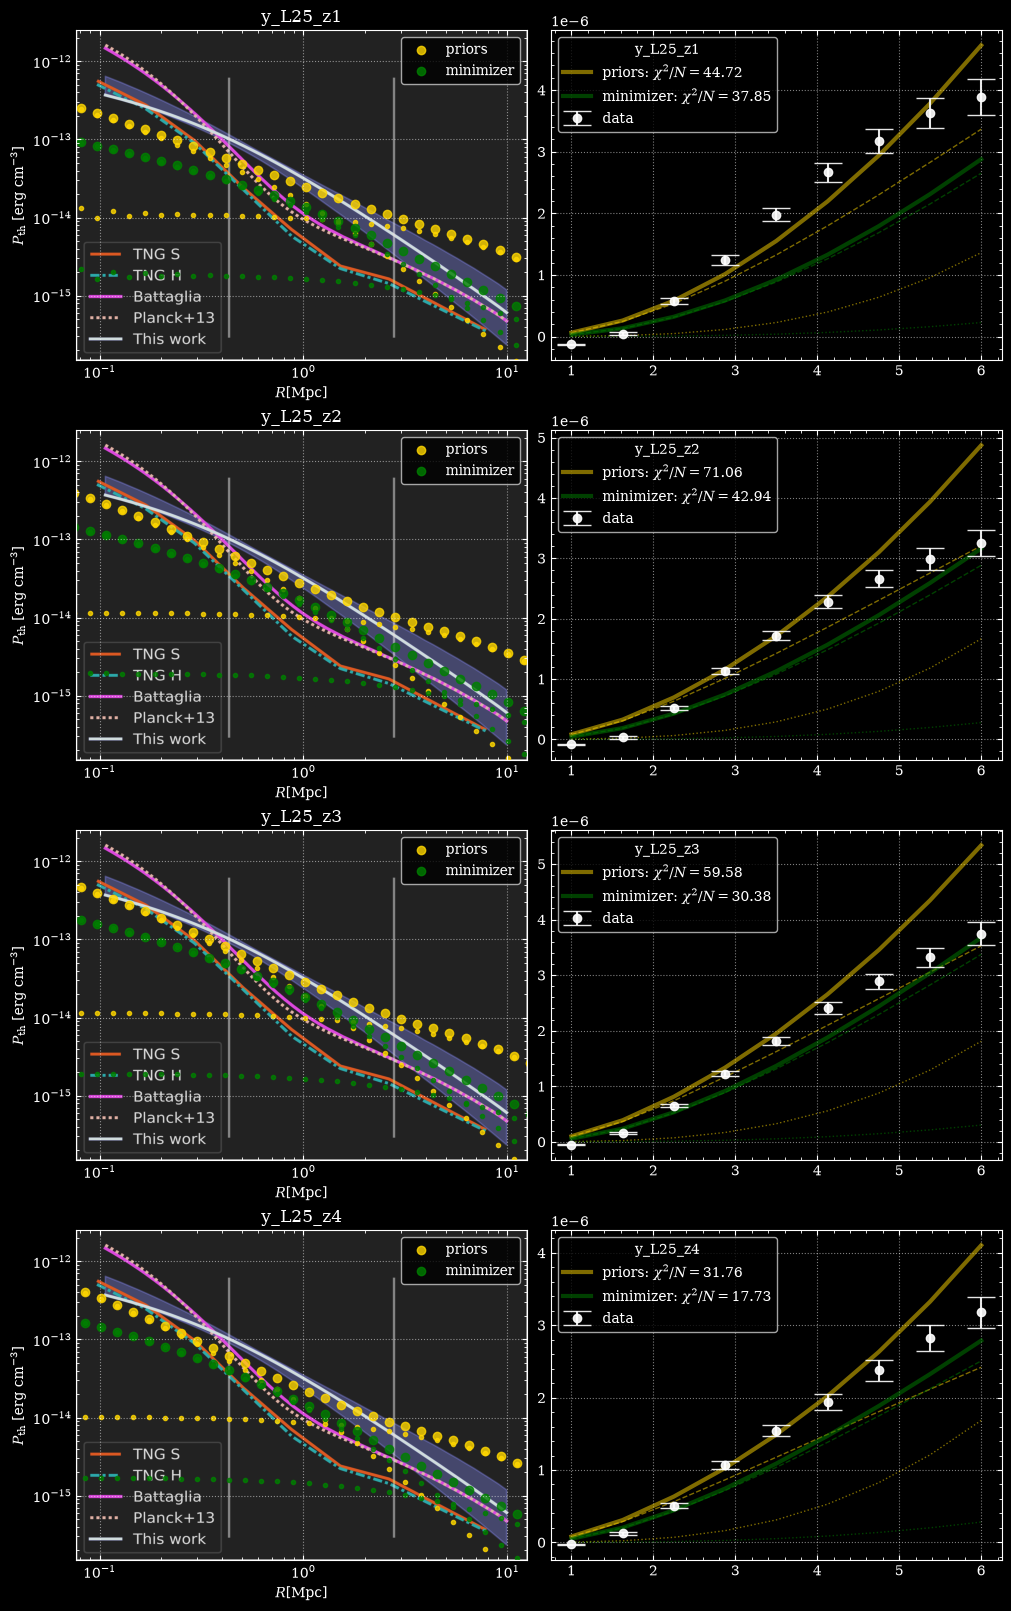

In [36]:
priorparams = {p_k: p_v['value'] if 'value' in p_v else p_v['ref']['loc'] for p_k, p_v in yamlinfo['params'].items()}

priors = get_param_results(priorparams, likelis)


minimizerparams = {k: mini_out.products()["minimum"][k] for k, v in yamlinfo['params'].items() if isinstance(v, dict) and "prior" in v}

minimizer_results = get_param_results(minimizerparams,likelis)


plot_results([
    {'label': 'priors', 'results': priors, 'color': 'gold'},
    {'label': 'minimizer', 'results': minimizer_results, 'color': 'green'},
    ], likelis)

# After submission

In [105]:
os.listdir(OUTPUT_PATH)

['RG25_test2',
 'RG25_all_fix_alpha',
 'RG25_test2_free_rho0_A2h',
 'test_rusty',
 'RG25_all_fix_gamma_beta',
 'CobayaRunRusty_LiuJoint_1',
 'RG25_all_free_rho0_A2h_xc',
 'RG25_test2_z4',
 'RG25_all_fix_gamma',
 'RG25_all_fix_alpha_beta',
 'RG25_test_z4',
 'RG25_all_fix_xc_alpha',
 'CobayaRunRustyTest_1',
 'RG25_test2_free_rho0_A2h_beta',
 'cobayarun_test',
 'RG25_all_fix_none',
 'RG25_test2_z2',
 'RG25_all_fix_xc_gamma',
 'RG25_all_fix_xc_beta',
 'RG25_all_fix_gamma_alpha',
 'RG25_test1',
 'RG25_all_fix_xc_gamma_beta',
 'RG25_all_fix_xc',
 '--f=',
 'RG25_test2_z3',
 'RG25_test_z1',
 'RG25_all_fix_xc_gamma_alpha',
 'RG25_all_fix_beta',
 'RG25_test_z2',
 'RG25_all_fix_xc_alpha_beta',
 'RG25_test_z3',
 'RG25_test2_z1',
 'minimizer_runs',
 'test_nersc']

['RG25_test2', 'RG25_all_fix_alpha', 'RG25_test2_free_rho0_A2h', 'RG25_all_free_rho0_A2h_gamma', 'RG25_m2_free_rho0_A2h_beta', 'test_rusty', 'RG25_all_free_rho0_A2h_xc_beta', 'RG25_all_fix_gamma_beta', 'CobayaRunRusty_LiuJoint_1', 'RG25_all_free_rho0_A2h_xc', 'RG25_test2_z4', 'RG25_all_fix_gamma', 'RG25_all_free_rho0_A2h_xc_alpha', 'RG25_all_fix_alpha_beta', 'RG25_m1_free_rho0_A2h_beta', 'RG25_test_z4', 'RG25_all_free_rho0_A2h_gamma_beta', 'RG25_all_fix_xc_alpha', 'RG25_z2_free_rho0_A2h_beta', 'CobayaRunRustyTest_1', 'RG25_test2_free_rho0_A2h_beta', 'RG25_all_free_rho0_A2h_alpha', 'cobayarun_test', 'RG25_all_fix_none', 'RG25_test2_z2', 'RG25_all_free_rho0_A2h_alpha_beta', 'RG25_all_fix_xc_gamma', 'RG25_z1_free_rho0_A2h_beta', 'RG25_all_free_rho0_A2h_xc_gamma', 'RG25_all_fix_xc_beta', 'RG25_all_fix_gamma_alpha', 'RG25_m3_free_rho0_A2h_beta', 'RG25_test1', 'RG25_all_fix_xc_gamma_beta', 'RG25_all_fix_xc', 'RG25_z3_free_rho0_A2h_beta', '--f=', 'RG25_test2_z3', 'RG25_test_z1', 'RG25_all_fix

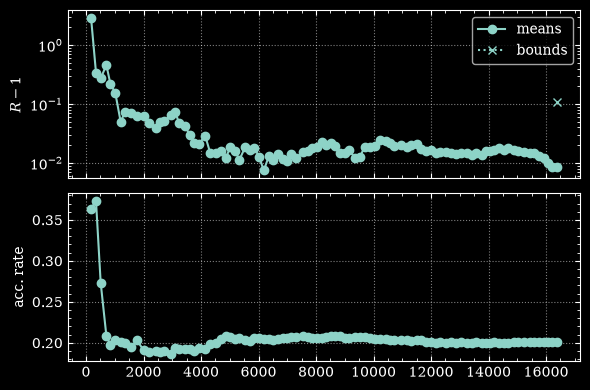

In [277]:
print(os.listdir(OUTPUT_PATH))

# Export the results to GetDist
runname = "RG25_m4_free_rho0_A2h_beta"

filename = f"{OUTPUT_PATH}/{runname}/{runname}"
folder,name = os.path.split(os.path.abspath(filename))

# Submission time (from run_chain.sh's queue_time.txt) and run duration (from runchains.py's runtime.txt)
queue_file, runtime_file = os.path.join(folder, "queue_time.txt"), os.path.join(folder, "runtime.txt")

if os.path.exists(queue_file):
    m = re.search(r"Submitted:\s*(.+)", open(queue_file).read())
    print(f"Submitted: {m.group(1).strip()}" if m else "Submitted: not found in queue_time.txt")
else:
    print("Submitted: queue_time.txt not found (run predates queue timing, or still queued)")

if os.path.exists(runtime_file):
    m = re.search(r"Runtime:\s*([\d.]+) seconds", open(runtime_file).read())
    print(f"Runtime: {float(m.group(1))/60:.1f} minutes" if m else "Runtime: not found in runtime.txt")
else:
    print("Runtime: not finished yet")

cobaya.samplers.mcmc.plot_progress(filename, figure_kwargs={"figsize": (6,4)})

plt.tight_layout()
plt.show()

### Get Samples

In [278]:
# Export the results to GetDist
gd_sample = cobaya.load_samples(filename, to_getdist=True)

with open(filename + ".input.yaml", "r") as f:
    yaml_load = yaml.safe_load(f)
    
mcmcparams = dict(zip(gd_sample.paramNames.list()[:-2], gd_sample.getMeans()[:-2]))
mcmcparams

INFO:samplecollection:Loaded 4089 sample points from '/mnt/ceph/users/cpopik/CAPPIBARAS_runs/RG25_m4_free_rho0_A2h_beta/RG25_m4_free_rho0_A2h_beta.1.txt'


[samplecollection] Loaded 4089 sample points from '/mnt/ceph/users/cpopik/CAPPIBARAS_runs/RG25_m4_free_rho0_A2h_beta/RG25_m4_free_rho0_A2h_beta.1.txt'


INFO:samplecollection:Loaded 4017 sample points from '/mnt/ceph/users/cpopik/CAPPIBARAS_runs/RG25_m4_free_rho0_A2h_beta/RG25_m4_free_rho0_A2h_beta.2.txt'


[samplecollection] Loaded 4017 sample points from '/mnt/ceph/users/cpopik/CAPPIBARAS_runs/RG25_m4_free_rho0_A2h_beta/RG25_m4_free_rho0_A2h_beta.2.txt'


INFO:samplecollection:Loaded 4040 sample points from '/mnt/ceph/users/cpopik/CAPPIBARAS_runs/RG25_m4_free_rho0_A2h_beta/RG25_m4_free_rho0_A2h_beta.3.txt'


[samplecollection] Loaded 4040 sample points from '/mnt/ceph/users/cpopik/CAPPIBARAS_runs/RG25_m4_free_rho0_A2h_beta/RG25_m4_free_rho0_A2h_beta.3.txt'


INFO:samplecollection:Loaded 4223 sample points from '/mnt/ceph/users/cpopik/CAPPIBARAS_runs/RG25_m4_free_rho0_A2h_beta/RG25_m4_free_rho0_A2h_beta.4.txt'


[samplecollection] Loaded 4223 sample points from '/mnt/ceph/users/cpopik/CAPPIBARAS_runs/RG25_m4_free_rho0_A2h_beta/RG25_m4_free_rho0_A2h_beta.4.txt'


{'rho0': np.float64(7.486319089827283),
 'beta_rho': np.float64(5.105995345956318),
 'A_2h_rho': np.float64(3.8017684533208707)}

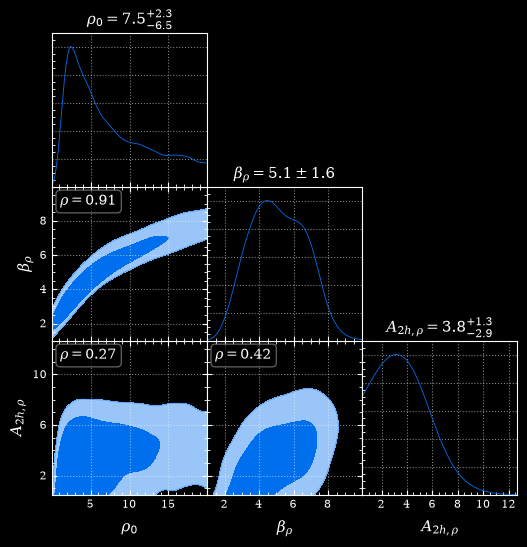

In [279]:
# Export the results to GetDist

gdplot = gdplt.get_subplot_plotter(chain_dir=folder)
gdplot.settings.title_limit_fontsize=14
gdplot.triangle_plot(
    gd_sample, list(mcmcparams.keys()), filled=True, title_fmt='latex', title_limit=1)
# param_limits={k: (yaml_load["params"][k]['prior']['min'], yaml_load["params"][k]['prior']['max']) for k in mcmcparams.keys()}

# Annotate each off-diagonal panel with the correlation coefficient from gd_sample.corr()
plot_params = list(mcmcparams.keys())
allnames = gd_sample.paramNames.list()
corr = gd_sample.corr()
idx = {name: allnames.index(name) for name in plot_params}
for i in range(len(plot_params)):
    for j in range(i):
        ax = gdplot.subplots[i, j]
        if ax is None:
            continue
        r = corr[idx[plot_params[i]], idx[plot_params[j]]]
        ax.text(0.05, 0.95, rf'$\rho={r:.2f}$', transform=ax.transAxes, ha='left', va='top',
                fontsize=10, bbox=dict(boxstyle='round', fc='k', ec='gray', alpha=0.7))

[model] *WARNING* Ignored blocks/options: ['sampler', 'shared', 'output', 'output_options']


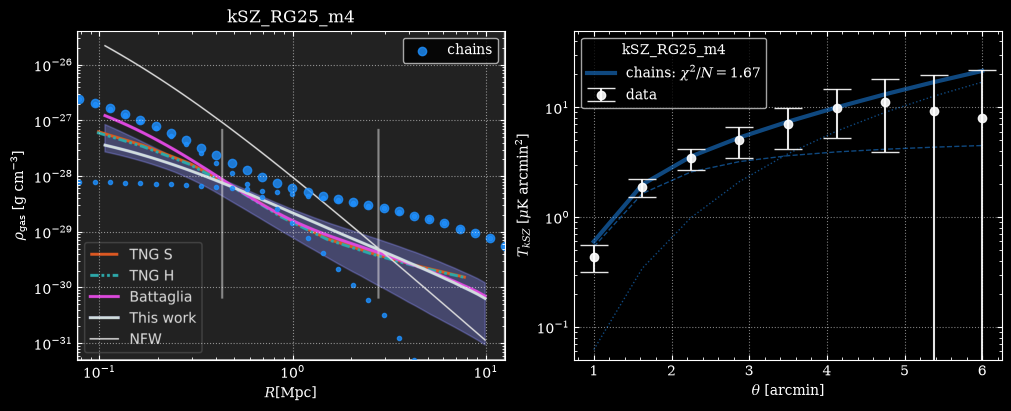

In [ ]:
yaml_load_edit = yaml_load.copy()
yaml_load_edit['SHMR'] = {'name': 'Gao2023', 'model':'Psat', 'Concentration': 'Duffy08'}
likelis = cobaya.get_model(yaml_load).likelihood

parschain = {p_k: mcmcparams[p_k] if p_k in mcmcparams else p_v['value'] for p_k, p_v in yaml_load['params'].items()}

chainresults = get_param_results(parschain, likelis)

plot_results([
    {'label': 'chains', 'results': chainresults, 'color': 'dodgerblue'},
    ], 
    likelis)

In [90]:
def _percentile_preserve_unit(arrs, p):
    # np.percentile on a list of astropy Quantity arrays silently drops units
    # if the numpy/astropy versions here don't route through __array_function__,
    # so pull the unit off the first draw, percentile the bare values, and
    # reattach it. Falls through untouched for plain ndarrays (no .unit).
    arrs = list(arrs)
    unit = getattr(arrs[0], 'unit', None)
    stacked = np.stack([np.asarray(a.value if unit is not None else a) for a in arrs])
    pct = np.percentile(stacked, p, axis=0)
    return pct * unit if unit is not None else pct


def get_confidence_results(likelis_in, gd_sample, yaml_load, percentiles=(16, 50, 84),
                            nsamp=300, seed=0, labels=None, cmap=plt.cm.viridis):
    """
    Draw a weighted-random subset of chain points and evaluate the forward
    model for each draw -- same fields get_param_results returns
    (prof1h/prof2h/proftot for the pre-projection 3D profile, 1h/2h/tot for
    the projected observable) -- then collapse the draws to pointwise
    percentile curves. Returns a `results_list` in the same format
    `plot_results` already expects, one entry per requested percentile, so
    e.g. percentiles=(16, 50, 84) plotted together traces a 68% band.
    """
    rng = np.random.default_rng(seed)

    allnames = gd_sample.paramNames.list()
    # Parameters actually sampled in the chain (those with a prior in the yaml)
    sampled = [p_k for p_k, p_v in yaml_load['params'].items()
               if isinstance(p_v, dict) and 'prior' in p_v and p_k in allnames]
    col = {p: allnames.index(p) for p in sampled}

    # Fixed baseline for every parameter the model expects; sampled ones get
    # overwritten per draw below.
    baseparams = {p_k: (p_v['value'] if isinstance(p_v, dict) and 'value' in p_v
                        else p_v['ref']['loc'] if isinstance(p_v, dict) and 'ref' in p_v
                        else p_v)
                  for p_k, p_v in yaml_load['params'].items()}

    # Weighted resample of chain rows (getdist weights encode sample multiplicity),
    # so unweighted percentiles over the draw already reflect the posterior.
    w = gd_sample.weights / gd_sample.weights.sum()
    draw = rng.choice(len(w), size=nsamp, replace=True, p=w)

    fields = ['1h', '2h', 'tot', 'prof1h', 'prof2h', 'proftot']
    stacked = {name: {f: [] for f in fields} for name in likelis_in}

    for idx in draw:
        params = dict(baseparams, **{p: gd_sample.samples[idx, col[p]] for p in sampled})
        res = get_param_results(params, likelis_in)
        for name, vers in res.items():
            for f in fields:
                stacked[name][f].append(vers[f])

    norm = plt.Normalize(min(percentiles), max(percentiles))
    results_list = []
    for p in percentiles:
        results = {}
        for name, likeli in likelis_in.items():
            curves = {f: _percentile_preserve_unit(stacked[name][f], p) for f in fields}
            delta = likeli.data.y - curves['tot']
            chi2_real = delta @ likeli.data.inv_cov @ delta  # diagnostic only: a pointwise
            # percentile curve isn't one self-consistent parameter draw, so this chi2
            # doesn't carry the same meaning it does in get_param_results.
            results[name] = dict(curves, chi2overN=chi2_real / len(likeli.data.x))
        results_list.append({
            'label': (labels[p] if labels else f'{p}th pct'),
            'results': results,
            'color': cmap(norm(p)),
        })

    return results_list

In [91]:
conf_results = get_confidence_results(likelis, gd_sample, yaml_load, percentiles=(16, 50, 84), nsamp=300)

plot_results(conf_results, likelis)

UnitConversionError: Can only apply 'subtract' function to dimensionless quantities when other argument is not a quantity (unless the latter is all zero/infinity/nan).

In [ ]:
# Evaluate the forward model over a weighted-random subset of chain points and
# STORE the resulting curves in `model_draws`, so the plotting/percentiles can be
# redone without re-running the (slow) model evaluations.

rng = np.random.default_rng(0)
nsamp = 300  # chain points to evaluate (forward-model eval is the bottleneck)

allnames = gd_sample.paramNames.list()
# Parameters actually sampled in the chain (those with a prior in the yaml)
sampled = [p_k for p_k, p_v in yaml_load['params'].items()
           if isinstance(p_v, dict) and 'prior' in p_v and p_k in allnames]
col = {p: allnames.index(p) for p in sampled}

# Fixed baseline for every parameter the model expects; the sampled ones get
# overwritten per draw below.
baseparams = {p_k: (p_v['value'] if isinstance(p_v, dict) and 'value' in p_v
                    else p_v['ref']['loc'] if isinstance(p_v, dict) and 'ref' in p_v
                    else p_v)
              for p_k, p_v in yaml_load['params'].items()}

# Weighted resample of chain rows (getdist weights encode sample multiplicity),
# so unweighted percentiles over the draw already reflect the posterior.
w = gd_sample.weights / gd_sample.weights.sum()
draw = rng.choice(len(w), size=nsamp, replace=True, p=w)

# Sampled-parameter value for each draw (same draw order as the stored curves),
# used for marginalized per-parameter effect plots.
draw_params = {p: gd_sample.samples[draw, col[p]] for p in sampled}

model_draws = {}
for name, likeli in likelis.items():
    curves = np.empty((nsamp, len(likeli.data.x)))
    for j, idx in enumerate(draw):
        params = dict(baseparams, **{p: gd_sample.samples[idx, col[p]] for p in sampled})
        curves[j] = np.asarray(likeli.model(params))
    model_draws[name] = {
        'x': np.asarray(likeli.data.x),
        'curves': curves,                          # (nsamp, nx) raw draws
        'data_y': np.asarray(likeli.data.y),
        'data_err': np.diag(likeli.data.cov)**0.5,
    }

print(f"Stored {nsamp} model curves for: {list(model_draws)}")

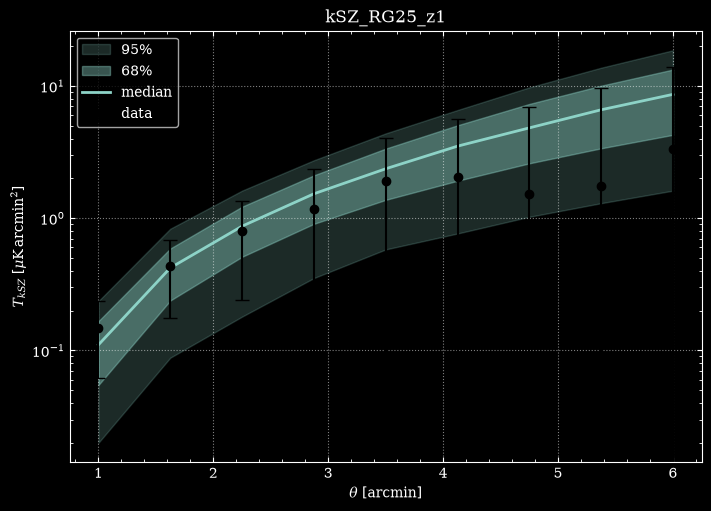

In [200]:
# Plot the stored confidence regions -- reads `model_draws`, no model evaluation
# here, so you can restyle / re-percentile freely without re-running the evals.

nrows = len(model_draws)
fig, axs = plt.subplots(nrows, 1, figsize=(7, 5*nrows), layout='constrained', squeeze=False)

for ax, (name, d) in zip(axs[:, 0], model_draws.items()):
    x = d['x']
    lo95, lo68, med, hi68, hi95 = np.percentile(d['curves'], [2.5, 16, 50, 84, 97.5], axis=0)

    ax.fill_between(x, lo95, hi95, color='C0', alpha=0.2, label='95%')
    ax.fill_between(x, lo68, hi68, color='C0', alpha=0.4, label='68%')
    ax.plot(x, med, color='C0', lw=2, label='median')
    ax.errorbar(x, d['data_y'], d['data_err'],
                marker='o', ls='None', capsize=5, color='k', label='data')

    ax.set(title=name, xlabel=r'$\theta$ [arcmin]')
    if "kSZ" in name:
        ax.set(yscale='log', ylabel=r'$T_{kSZ}\ [\mu\mathrm{K}\,\mathrm{arcmin}^2]$')
    elif "tSZ" in name:
        ax.set(ylabel=r'$y$')
    ax.legend()

plt.show()

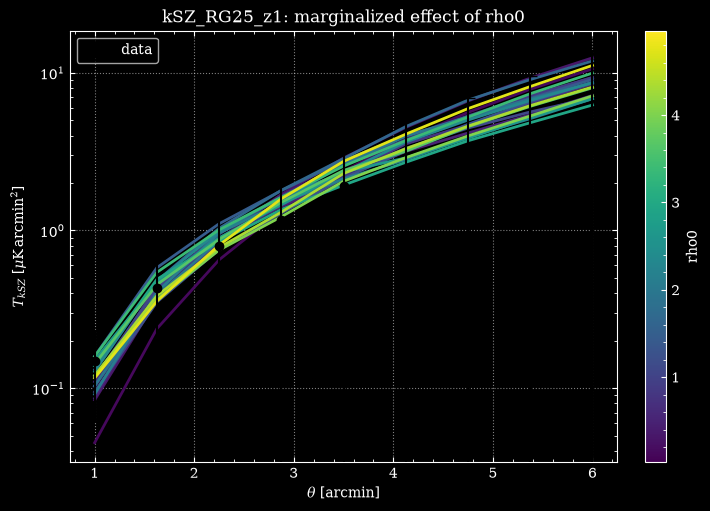

In [203]:
# Marginalized effect of a SINGLE parameter on the model output.
# Unlike the prior-range cell (which fixes all other params at defaults), here we
# bin the chain draws by one parameter's value while the OTHER params keep
# following their posterior -- i.e. they're marginalized over. Each band/line
# shows the model output for draws in that slice of the parameter's posterior.

param = 'rho0'   # <-- parameter to isolate (must be in `sampled`)
nbins = 20        # number of equal-count posterior slices

pv = draw_params[param]
# Quantile edges so each bin holds ~equal numbers of draws across the posterior
edges = np.quantile(pv, np.linspace(0, 1, nbins + 1))
which = np.clip(np.digitize(pv, edges[1:-1]), 0, nbins - 1)

cmap = plt.cm.viridis
norm = plt.Normalize(pv.min(), pv.max())

nrows = len(model_draws)
fig, axs = plt.subplots(nrows, 1, figsize=(7, 5*nrows), layout='constrained', squeeze=False)

for ax, (name, d) in zip(axs[:, 0], model_draws.items()):
    x = d['x']
    for b in range(nbins):
        sel = which == b
        if not sel.any():
            continue
        med = np.median(d['curves'][sel], axis=0)   # median model output in this slice
        ax.plot(x, med, color=cmap(norm(pv[sel].mean())), lw=2)

    ax.errorbar(x, d['data_y'], d['data_err'],
                marker='o', ls='None', capsize=5, color='k', label='data', zorder=5)
    sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
    fig.colorbar(sm, ax=ax, label=param)

    ax.set(title=f"{name}: marginalized effect of {param}", xlabel=r'$\theta$ [arcmin]')
    if "kSZ" in name:
        ax.set(yscale='log', ylabel=r'$T_{kSZ}\ [\mu\mathrm{K}\,\mathrm{arcmin}^2]$')
    elif "tSZ" in name:
        ax.set(ylabel=r'$y$')
    ax.legend()

plt.show()

INFO:samplecollection:Loaded 1425 sample points from '/mnt/ceph/users/cpopik/CAPPIBARAS_runs/RG25_z1_free_rho0_A2h_beta/RG25_z1_free_rho0_A2h_beta.1.txt'


[samplecollection] Loaded 1425 sample points from '/mnt/ceph/users/cpopik/CAPPIBARAS_runs/RG25_z1_free_rho0_A2h_beta/RG25_z1_free_rho0_A2h_beta.1.txt'


INFO:samplecollection:Loaded 1505 sample points from '/mnt/ceph/users/cpopik/CAPPIBARAS_runs/RG25_z1_free_rho0_A2h_beta/RG25_z1_free_rho0_A2h_beta.2.txt'


[samplecollection] Loaded 1505 sample points from '/mnt/ceph/users/cpopik/CAPPIBARAS_runs/RG25_z1_free_rho0_A2h_beta/RG25_z1_free_rho0_A2h_beta.2.txt'


INFO:samplecollection:Loaded 1560 sample points from '/mnt/ceph/users/cpopik/CAPPIBARAS_runs/RG25_z1_free_rho0_A2h_beta/RG25_z1_free_rho0_A2h_beta.3.txt'


...

INFO:samplecollection:Loaded 967 sample points from '/mnt/ceph/users/cpopik/CAPPIBARAS_runs/RG25_z4_free_rho0_A2h_beta/RG25_z4_free_rho0_A2h_beta.3.txt'


[samplecollection] Loaded 967 sample points from '/mnt/ceph/users/cpopik/CAPPIBARAS_runs/RG25_z4_free_rho0_A2h_beta/RG25_z4_free_rho0_A2h_beta.3.txt'


INFO:samplecollection:Loaded 1040 sample points from '/mnt/ceph/users/cpopik/CAPPIBARAS_runs/RG25_z4_free_rho0_A2h_beta/RG25_z4_free_rho0_A2h_beta.4.txt'


[samplecollection] Loaded 1040 sample points from '/mnt/ceph/users/cpopik/CAPPIBARAS_runs/RG25_z4_free_rho0_A2h_beta/RG25_z4_free_rho0_A2h_beta.4.txt'


[root] *WARNING* outlier fraction 0.0014566642388929353 


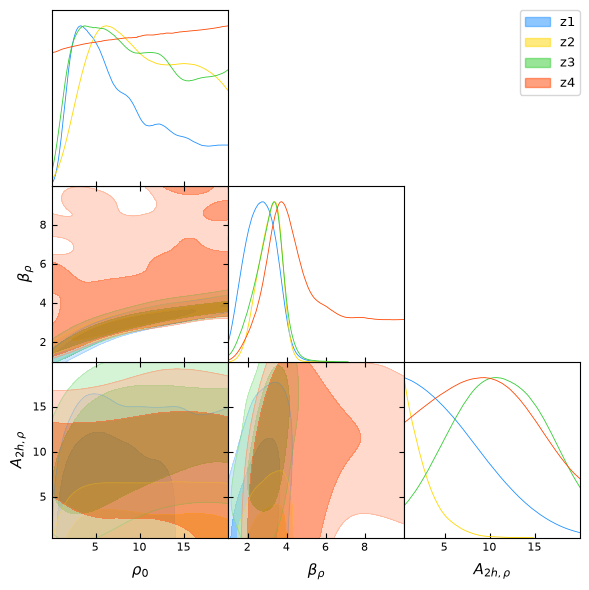

In [ ]:
plt.style.use('default')

# Corner plot comparing RG25_z{1..4}_free_rho0_A2h_beta -- one MCSamples per
# redshift bin, overlaid on a single triangle plot with a different color each.
zbin_runs = {
    'z1': "RG25_z1_free_rho0_A2h_beta",
    'z2': "RG25_z2_free_rho0_A2h_beta",
    'z3': "RG25_z3_free_rho0_A2h_beta",
    'z4': "RG25_z4_free_rho0_A2h_beta",
}

zbin_samples = {}
for zbin, runname in zbin_runs.items():
    zbin_samples[zbin] = cobaya.load_samples(f"{OUTPUT_PATH}/{runname}/{runname}", to_getdist=True)

# All four runs share the same free parameters; strip the trailing derived
# params (chi2/minuslogpost), same convention as mcmcparams above.
plot_params = list(zbin_samples['z1'].paramNames.list())[:-2]

zbin_colors = ['dodgerblue', 'gold', 'limegreen', 'orangered']
contour_alpha = 0.5  # lower = less occlusion between overlapping z-bin contours

gdplot = gdplt.get_subplot_plotter()
gdplot.settings.title_limit_fontsize = 14
gdplot.triangle_plot(
    list(zbin_samples.values()), plot_params, filled=True,
    legend_labels=list(zbin_samples.keys()),
    contour_colors=zbin_colors,
    contour_args=[{'alpha': contour_alpha}] * len(zbin_samples),
)
plt.show()

plt.style.use('dark_background')